In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
df_olimpiadas = pd.read_csv('olimpiadas_medalhas_arrumado.csv.', encoding='utf-8')
display(df_olimpiadas.head())

df_paraolimpiadas = pd.read_csv('paralimpiada_medalhas_arrumado.csv', encoding='utf-8')
display(df_paraolimpiadas.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
2,3,China,12,302,227,197,726,CHN
3,4,Grã-Bretanha,30,300,338,344,982,GBR
4,5,França,30,240,280,298,818,FRA


,País,№,Ouro,Prata,Bronze,Total,NOC
0,África do Sul,11,121,95,88,304,RSA
1,Alemanha,8,199,266,253,718,GER
2,Alemanha,8,322,260,246,828,FRG
3,Alemanha,1,0,3,1,4,GDR
4,Angola,6,4,3,1,8,ANG


In [5]:
df_olimpico_total = df_olimpiadas.groupby('País')['Total'].sum().reset_index()
df_olimpico_total = df_olimpico_total.sort_values(by='Total', ascending=False)
df_olimpico_total.columns = ['País', 'Total_Olimpico']

df_paralimpico_total = df_paraolimpiadas.groupby('País')['Total'].sum().reset_index()
df_paralimpico_total = df_paralimpico_total.sort_values(by='Total', ascending=False)
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

In [6]:
display(df_olimpico_total.head())
display(df_paralimpico_total.head())

,País,Total_Olimpico
53,Estados Unidos,2762
143,União Soviética,1010
65,Grã-Bretanha,982
60,França,818
31,China,726


,País,Total_Paralimpico
40,Estados Unidos,2283
48,Grã-Bretanha,1914
0,Alemanha,1550
22,China,1237
6,Austrália,1205


In [9]:
df_olimpico_total.columns = ['País', 'Total_Olimpico']
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

df_olim_e_para = pd.merge(df_olimpico_total, df_paralimpico_total, on='País', how='outer')
df_olim_e_para.fillna(0, inplace=True)
display(df_olim_e_para.head())


,País,Total_Olimpico,Total_Paralimpico
0,Afeganistão,2.0,0.0
1,Alemanha,685.0,1550.0
2,Alemanha Ocidental,204.0,0.0
3,Alemanha Oriental,409.0,0.0
4,Angola,0.0,8.0


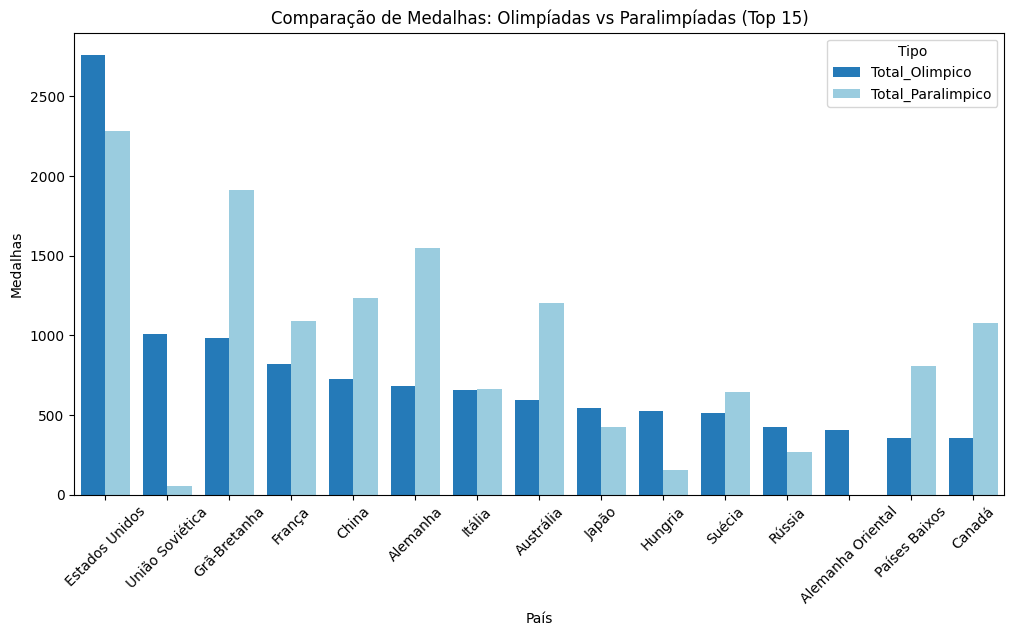

In [10]:
df_top = df_olim_e_para.nlargest(15, 'Total_Olimpico')

df_plot = df_top.melt(id_vars='País', value_vars=['Total_Olimpico', 'Total_Paralimpico'], 
                      var_name='Tipo', value_name='Medalhas')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo',  palette=["#0c7ed0", "#8ED1EB"])
plt.xticks(rotation=45)
plt.title('Comparação de Medalhas: Olimpíadas vs Paralimpíadas (Top 15)')
plt.show()